# Mini Projet — Gestion du déséquilibre de classes
## Étape 3 : Modèle Baseline — Fine-tuning DziriBERT
###  Version Google Colab — GPU Ready
**Module :** Machine Learning | **Enseignante :** Dr. Soraya Cheriguene  
**Université :** USDB — Master 1 SD & TAL | **Année :** 2025–2026

---
##  AVANT DE COMMENCER — Checklist Colab
1. `Runtime → Change runtime type → T4 GPU → Save`
2. Exécuter les cellules dans l'ordre
3. Avoir les fichiers `train_set.csv`, `val_set.csv`, `test_set.csv` prêts à uploader

## CELLULE 1 — Installation des dépendances

In [ ]:
# ─── Installation ───────────────────────────────────────────
# À exécuter en premier, une seule fois par session Colab
!pip install transformers datasets torch scikit-learn seaborn -q

print("✅ Installation terminée — continuez à la cellule suivante")

✅ Installation terminée — continuez à la cellule suivante


In [ ]:
!pip install --upgrade numpy


## CELLULE 2 — Upload des fichiers CSV depuis ta machine

In [ ]:
# ─── Upload des fichiers produits par l'Étape 2 ─────────────
# Une fenêtre va s'ouvrir → sélectionne les 3 fichiers :
#   train_set.csv  |  val_set.csv  |  test_set.csv
from google.colab import files
print("Sélectionne les 3 fichiers CSV (train_set, val_set, test_set)...")
uploaded = files.upload()

import os
print("\nFichiers disponibles :")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f"  ✅ {f}")

# Vérification que les 3 fichiers sont bien là
required = ['train_set.csv', 'val_set.csv', 'test_set.csv']
missing  = [f for f in required if not os.path.exists(f)]
if missing:
    print(f"\n⚠️  Fichiers manquants : {missing}")
else:
    print("\n✅ Tous les fichiers sont présents — tu peux continuer !")

Sélectionne les 3 fichiers CSV (train_set, val_set, test_set)...


Saving test_set.csv to test_set.csv
Saving train_set.csv to train_set.csv
Saving val_set.csv to val_set.csv

Fichiers disponibles :
  ✅ train_set.csv
  ✅ val_set.csv
  ✅ test_set.csv

✅ Tous les fichiers sont présents — tu peux continuer !


CELLULE 2 — Upload des fichiers CSV depuis ta machine

In [ ]:
# Fix for numpy/scipy/seaborn compatibility issue
!pip install --upgrade scipy seaborn
# IMPORTANT: After running this cell, please restart the Colab runtime (Runtime -> Restart runtime)
# and then re-run all cells from the beginning to ensure the new package versions are loaded correctly.

import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import label_binarize

# ─── Seed global obligatoire ────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# ─── Device ─────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Pas de GPU — vas dans Runtime → Change runtime type → T4 GPU")

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print("\n✅ Imports OK")

Device : cuda
✅ GPU détecté : Tesla T4

✅ Imports OK


In [ ]:
df_train = pd.read_csv('train_set.csv')
df_val   = pd.read_csv('val_set.csv')
df_test  = pd.read_csv('test_set.csv')

print(f"Train : {len(df_train)} tweets")
print(f"Val   : {len(df_val)} tweets")
print(f"Test  : {len(df_test)} tweets")

LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']

for df in [df_train, df_val, df_test]:
    if 'label_id' not in df.columns:
        df['label_id'] = df['label'].map(LABEL2ID)

print("\nDistribution du train (déséquilibré — aucun rééquilibrage appliqué) :")
for cls, cnt in df_train['label'].value_counts().items():
    print(f"  {cls:<12} : {cnt} ({cnt/len(df_train)*100:.1f}%)")

Train : 3512 tweets
Val   : 753 tweets
Test  : 753 tweets

Distribution du train (déséquilibré — aucun rééquilibrage appliqué) :
  Positive     : 1820 (51.8%)
  Negative     : 1210 (34.5%)
  Neutral      : 482 (13.7%)


## CELLULE 5 — Tokenizer et Dataset PyTorch

In [ ]:
MODEL_NAME = 'alger-ia/dziribert'
print(f"Chargement du tokenizer {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer chargé — vocab size : {tokenizer.vocab_size}")

Chargement du tokenizer alger-ia/dziribert...


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ Tokenizer chargé — vocab size : 50000


In [ ]:
MAX_LEN    = 128
BATCH_SIZE = 16   # Imposé dans l'énoncé

class TwiflDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = [str(t) if not pd.isna(t) else '' for t in texts]
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TwiflDataset(df_train['text'].values, df_train['label_id'].values, tokenizer)
val_dataset   = TwiflDataset(df_val['text'].values,   df_val['label_id'].values,   tokenizer)
test_dataset  = TwiflDataset(df_test['text'].values,  df_test['label_id'].values,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Datasets créés")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ Datasets créés
   Train batches : 220
   Val batches   : 48
   Test batches  : 48


## CELLULE 6 — Fonctions d'entraînement et métriques

In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels), np.array(all_probs)


def compute_gmean(y_true, y_pred):
    recalls = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    gmean = np.prod(recalls) ** (1.0 / len(recalls))
    return gmean, recalls


def compute_auc_pr(y_true, y_probs, n_classes=3):
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    auc_pr_per_class = [average_precision_score(y_bin[:, i], y_probs[:, i]) for i in range(n_classes)]
    return np.mean(auc_pr_per_class), auc_pr_per_class


def print_all_metrics(test_labels, test_preds, test_probs, config_name):
    """Affiche toutes les métriques obligatoires de l'énoncé."""
    f1_macro       = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    f1_per_cls     = f1_score(test_labels, test_preds, average=None,    zero_division=0)
    prec_per_cls   = precision_score(test_labels, test_preds, average=None, zero_division=0)
    rec_per_cls    = recall_score(test_labels,    test_preds, average=None, zero_division=0)
    auc_pr, auc_pc = compute_auc_pr(test_labels, test_probs)
    gmean, _       = compute_gmean(test_labels, test_preds)
    accuracy       = accuracy_score(test_labels, test_preds)

    print(f"\n{'='*60}")
    print(f"MÉTRIQUES — {config_name}")
    print(f"{'='*60}")
    print(f"  F1-macro       : {f1_macro:.4f}  ← MÉTRIQUE PRINCIPALE")
    print(f"  AUC-PR (macro) : {auc_pr:.4f}")
    print(f"  G-mean         : {gmean:.4f}")
    print(f"  Accuracy       : {accuracy:.4f}  ← trompeuse (données déséquilibrées)")
    print(f"\n  {'Classe':<12} {'F1':>6} {'Precision':>10} {'Rappel':>8} {'AUC-PR':>8}")
    print(f"  {'-'*48}")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:<12} {f1_per_cls[i]:>6.4f} {prec_per_cls[i]:>10.4f} {rec_per_cls[i]:>8.4f} {auc_pc[i]:>8.4f}")

    print(f"\n{classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0)}")

    return {
        'configuration': config_name,
        'f1_macro':    round(float(f1_macro), 4),
        'f1_negative': round(float(f1_per_cls[0]), 4),
        'f1_neutral':  round(float(f1_per_cls[1]), 4),
        'f1_positive': round(float(f1_per_cls[2]), 4),
        'auc_pr':      round(float(auc_pr), 4),
        'gmean':       round(float(gmean), 4),
        'accuracy':    round(float(accuracy), 4),
    }

print("✅ Fonctions définies")

✅ Fonctions définies


## CELLULE 7 — Initialisation du modèle Baseline

In [ ]:
# Hyperparamètres imposés par l'énoncéS
NUM_EPOCHS   = 5
LR           = 2e-5
WARMUP_RATIO = 0.1

set_seed()

print(f"Chargement de DziriBERT ({MODEL_NAME})...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
).to(DEVICE)

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"✅ Modèle chargé sur {DEVICE}")
print(f"   Total steps  : {total_steps}")
print(f"   Warmup steps : {warmup_steps}")
print(f"   ⚠️  Baseline : CrossEntropy standard — aucun rééquilibrage")

Chargement de DziriBERT (alger-ia/dziribert)...


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

✅ Modèle chargé sur cuda
   Total steps  : 1100
   Warmup steps : 110
   ⚠️  Baseline : CrossEntropy standard — aucun rééquilibrage


## CELLULE 8 — Entraînement (5 epochs)

In [ ]:
print("="*60)
print("ENTRAÎNEMENT BASELINE — DziriBERT")
print("="*60)

history = {'train_loss': [], 'val_loss': [], 'val_f1_macro': []}
best_val_f1, best_epoch = 0, 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_preds, val_labels, val_probs = evaluate(model, val_loader, DEVICE)
    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1_macro'].append(val_f1)

    print(f"  Train Loss   : {train_loss:.4f}")
    print(f"  Val Loss     : {val_loss:.4f}")
    print(f"  Val F1-macro : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1, best_epoch = val_f1, epoch
        torch.save(model.state_dict(), 'baseline_best_model.pt')
        print(f"  ✅ Meilleur modèle sauvegardé (epoch {epoch})")

print(f"\nEntraînement terminé ! Meilleure epoch : {best_epoch} (F1-macro val = {best_val_f1:.4f})")

ENTRAÎNEMENT BASELINE — DziriBERT

Epoch 1/5
  Train Loss   : 0.7964
  Val Loss     : 0.6741
  Val F1-macro : 0.6338
  ✅ Meilleur modèle sauvegardé (epoch 1)

Epoch 2/5
  Train Loss   : 0.5177
  Val Loss     : 0.7189
  Val F1-macro : 0.6583
  ✅ Meilleur modèle sauvegardé (epoch 2)

Epoch 3/5
  Train Loss   : 0.3083
  Val Loss     : 0.9854
  Val F1-macro : 0.6065

Epoch 4/5
  Train Loss   : 0.1777
  Val Loss     : 1.1371
  Val F1-macro : 0.6464

Epoch 5/5
  Train Loss   : 0.1174
  Val Loss     : 1.2457
  Val F1-macro : 0.6397

Entraînement terminé ! Meilleure epoch : 2 (F1-macro val = 0.6583)


In [ ]:
print("="*60)
print("ENTRAÎNEMENT BASELINE — DziriBERT")
print("="*60)

history = {'train_loss': [], 'val_loss': [], 'val_f1_macro': []}
best_val_f1, best_epoch = 0, 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_preds, val_labels, val_probs = evaluate(model, val_loader, DEVICE)
    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1_macro'].append(val_f1)

    print(f"  Train Loss   : {train_loss:.4f}")
    print(f"  Val Loss     : {val_loss:.4f}")
    print(f"  Val F1-macro : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1, best_epoch = val_f1, epoch
        torch.save(model.state_dict(), 'baseline_best_model.pt')
        print(f"  ✅ Meilleur modèle sauvegardé (epoch {epoch})")

print(f"\nEntraînement terminé ! Meilleure epoch : {best_epoch} (F1-macro val = {best_val_f1:.4f})")

# ============================================================
# ÉVALUATION FINALE — Baseline
# ============================================================
print("="*60)
print("ÉVALUATION FINALE — Baseline DziriBERT")
print("="*60)

# Charger le meilleur modèle sauvegardé
model.load_state_dict(torch.load('baseline_best_model.pt', map_location=DEVICE))

# Évaluer sur le test set
test_loss, test_preds, test_labels, test_probs = evaluate(model, test_loader, DEVICE)

# Récupérer toutes les métriques
results_baseline = print_all_metrics(test_labels, test_preds, test_probs, "Baseline DziriBERT")

# Affichage résumé des métriques principales
print("\nRésumé des métriques principales (Baseline DziriBERT)")
print("="*60)
print(f"F1-macro   : {results_baseline['f1_macro']:.4f}")
print(f"F1-Positive: {results_baseline['f1_positive']:.4f}")
print(f"F1-Negative: {results_baseline['f1_negative']:.4f}")
print(f"F1-Neutral : {results_baseline['f1_neutral']:.4f}")
print(f"AUC-PR     : {results_baseline['auc_pr']:.4f}")
print(f"G-Mean     : {results_baseline['gmean']:.4f}")


ENTRAÎNEMENT BASELINE — DziriBERT

Epoch 1/5
  Train Loss   : 0.3442
  Val Loss     : 0.7189
  Val F1-macro : 0.6583
  ✅ Meilleur modèle sauvegardé (epoch 1)

Epoch 2/5
  Train Loss   : 0.3429
  Val Loss     : 0.7189
  Val F1-macro : 0.6583

Epoch 3/5
  Train Loss   : 0.3396
  Val Loss     : 0.7189
  Val F1-macro : 0.6583

Epoch 4/5
  Train Loss   : 0.3411
  Val Loss     : 0.7189
  Val F1-macro : 0.6583

Epoch 5/5
  Train Loss   : 0.3410
  Val Loss     : 0.7189
  Val F1-macro : 0.6583

Entraînement terminé ! Meilleure epoch : 1 (F1-macro val = 0.6583)
ÉVALUATION FINALE — Baseline DziriBERT

MÉTRIQUES — Baseline DziriBERT
  F1-macro       : 0.6741  ← MÉTRIQUE PRINCIPALE
  AUC-PR (macro) : 0.7504
  G-mean         : 0.6448
  Accuracy       : 0.7224  ← trompeuse (données déséquilibrées)

  Classe           F1  Precision   Rappel   AUC-PR
  ------------------------------------------------
  Negative     0.7379     0.6500   0.8533   0.7668
  Neutral      0.5287     0.6571   0.4423   0.6421
 

## CELLULE 11 — Matrice de confusion

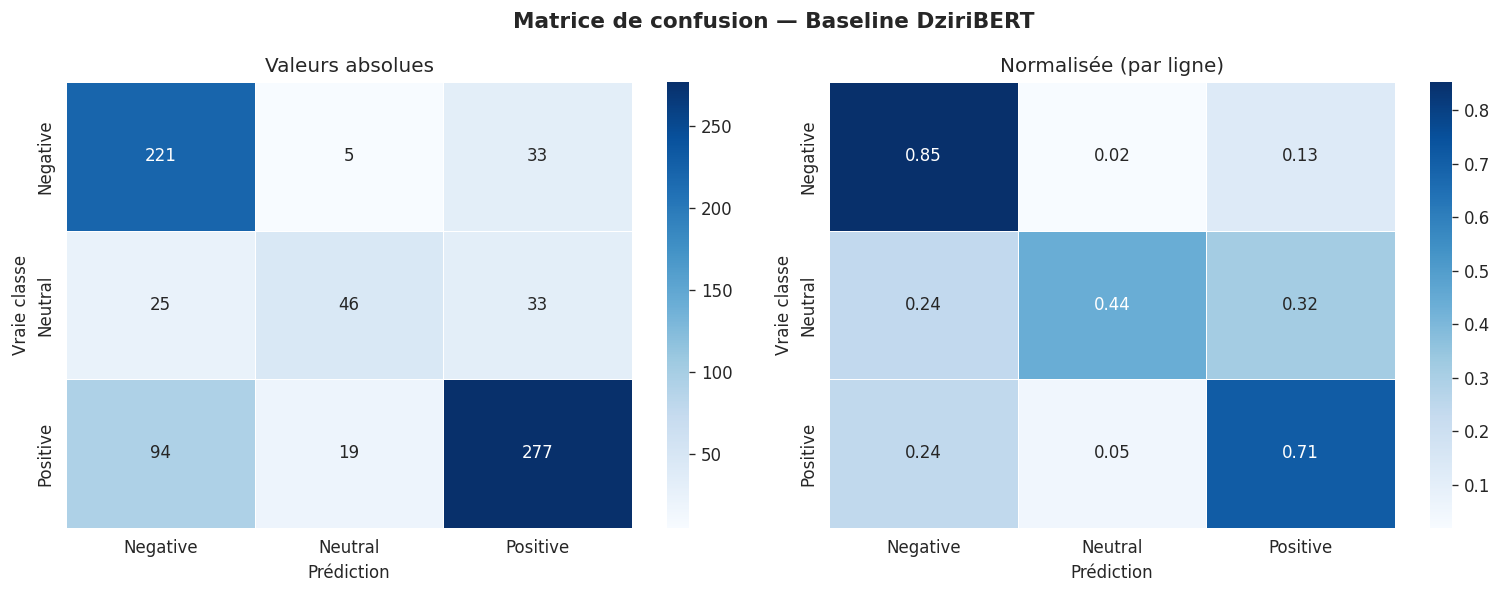

In [ ]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrice de confusion — Baseline DziriBERT', fontsize=13, fontweight='bold')

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Valeurs absolues', 'Normalisée (par ligne)'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vraie classe')

plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

## CELLULE 12 — Courbes Precision-Rappel

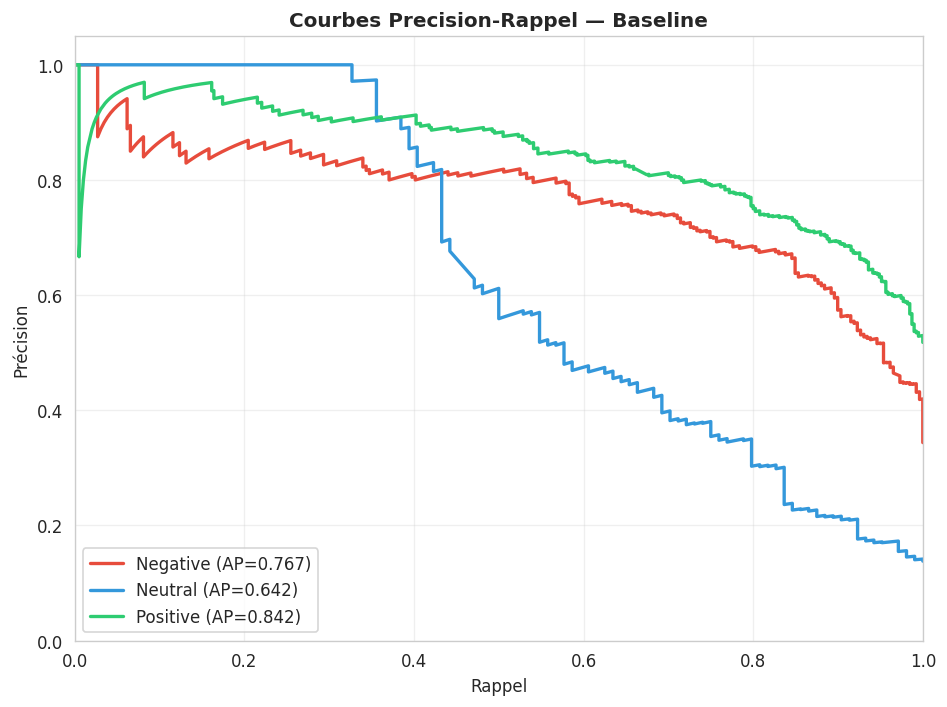

In [ ]:
y_bin = label_binarize(test_labels, classes=[0, 1, 2])
_, auc_pc = compute_auc_pr(test_labels, test_probs)
COLORS_CLS = {'Negative': '#e74c3c', 'Neutral': '#3498db', 'Positive': '#2ecc71'}

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Courbes Precision-Rappel — Baseline', fontsize=12, fontweight='bold')
for i, cls in enumerate(CLASS_NAMES):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], test_probs[:, i])
    ax.plot(recall, precision, lw=2, label=f'{cls} (AP={auc_pc[i]:.3f})', color=COLORS_CLS[cls])
ax.set_xlabel('Rappel')
ax.set_ylabel('Précision')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## CELLULE 13 — Sauvegarde des résultats de référence

In [ ]:
all_results = [results_baseline]
with open('results_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print("✅ results_comparison.json sauvegardé")

✅ results_comparison.json sauvegardé
